In [1]:
] activate .

  Activating project at `~/devansh/kernel_tests_jl/SpatiotemporalGPs.jl/examples`


In [2]:
# use this command to add the src package into the current environment

In [3]:
# ] dev .. 

In [4]:
] st

Status `~/devansh/kernel_tests_jl/SpatiotemporalGPs.jl/examples/Project.toml`
  [052768ef] CUDA v5.8.3
  [91a5bcdd] Plots v1.40.17
  [73b3b457] SpatiotemporalGPs v1.0.1-DEV `..`
  [90137ffa] StaticArrays v1.9.14
  [37e2e46d] LinearAlgebra v1.11.0


In [5]:
using Revise

In [6]:
using SpatiotemporalGPs
# include("../src/SpatiotemporalGPs.jl")

[ Info: Precompiling SpatiotemporalGPs [73b3b457-46a4-4dae-aece-b1ff83e37843] (cache misses: include_dependency fsize change (2), wrong dep version loaded (2))


In [7]:
using StaticArrays, LinearAlgebra, Plots

In [8]:
## CUDA
using CUDA
using BenchmarkTools

In [9]:
for device in CUDA.devices()
    @show capability(device)
end

capability(device) = v"8.6.0"


In [10]:
CUDA.versioninfo()

CUDA toolchain: 
- runtime 12.9, artifact installation
- driver 535.183.1 for 12.2
- compiler 12.9

CUDA libraries: 
- CUBLAS: 12.9.1
- CURAND: 10.3.10
- CUFFT: 11.4.1
- CUSOLVER: 11.7.5
- CUSPARSE: 12.5.10
- CUPTI: 2025.2.1 (API 28.0.0)
- NVML: 12.0.0+535.183.1

Julia packages: 
- CUDA: 5.8.3
- CUDA_Driver_jll: 13.0.0+0
- CUDA_Compiler_jll: 0.2.0+0
- CUDA_Runtime_jll: 0.19.0+0

Toolchain:
- Julia: 1.11.2
- LLVM: 16.0.6

1 device:
  0: NVIDIA GeForce RTX 3050 Ti Laptop GPU (sm_86, 3.198 GiB / 4.000 GiB available)


In [11]:
# if CUDA.functional()
    
#     println("Praise be - cuda is available!!")
    
#     # provide a overload for A * B' that works with CUDA
#     function LinearAlgebra.mul!(C::CuArray{F, 2, M},
#         A::UpperTriangular{F, CuArray{F, 2, M}},
#         B::Adjoint{F, CuArray{F, 2, M}}) where {F, M}
    
#     # force the copy when running with adjoint
#     return mul!(C, A, copy(B) )
#     end
# end

In [12]:
CUDA.free_memory() / 2^20

3193.1875

In [13]:
CUDA.total_memory() / 2^20

3902.1875

## Define the Problem

In [14]:
# setup the spatial and temporal kernels
σt = 2.0   # m/s
σs = 1.0   # m/s
lt = 3*60.0  # minutes
ls = 3.0   # km

kt = Matern(3/2, σt, lt)
ks = Matern(1/2, σs, ls)

# determine the temporal step size
Δt = 5.0 # minutes
Δx = 3.0 # km

# create the spatial domain
xs = 0:Δx:7.0
ys = 0:Δx:10.0

grid_pts = vec([@SVector[x, y] for x in xs, y in ys]);

## Create Synthetic Data

In [15]:
# let us generate the synthetic data first
tmax = 4 * 60.0 # minutes
synthetic_data = STGPKF.generate_spatiotemporal_process(xs, ys, Δt, tmax, ks, kt);

In [16]:
@show length(synthetic_data.ts)
@show prod(size(synthetic_data.data));

length(synthetic_data.ts) = 48
prod(size(synthetic_data.data)) = 576


In [17]:
# # visualize the ground truth data
# @gif for k=1:length(synthetic_data.ts)
#     heatmap(synthetic_data.xs, synthetic_data.ys, synthetic_data.data[:, :, k]', clims=(-5,5))
#     title!("k = $k")
#     xlabel!("x")
#     ylabel!("y")
#     plot!(aspect_ratio=:equal)
# end

## lets start estimating

In [18]:
# create the STGPKF Problem
problem = STGPKFProblem(grid_pts, ks, kt, Δt)

STGPKFProblem{SVector{2, Float64}, Float64, Vector{SVector{2, Float64}}, SpatiotemporalGPs.STGPKF.Matern12{Float64}, SpatiotemporalGPs.STGPKF.Matern32{Float64}, SpatiotemporalGPs.STGPKF.DiscreteTimeStateSpaceModel{SMatrix{2, 2, Float64, 4}, SMatrix{2, 2, Float64, 4}, SMatrix{1, 2, Float64, 2}, Float64}, Symmetric{Float64, Matrix{Float64}}, Symmetric{Float64, Matrix{Float64}}}(SVector{2, Float64}[[0.0, 0.0], [3.0, 0.0], [6.0, 0.0], [0.0, 3.0], [3.0, 3.0], [6.0, 3.0], [0.0, 6.0], [3.0, 6.0], [6.0, 6.0], [0.0, 9.0], [3.0, 9.0], [6.0, 9.0]], SpatiotemporalGPs.STGPKF.Matern12{Float64}(1.0, 0.3333333333333333), SpatiotemporalGPs.STGPKF.Matern32{Float64}(4.0, 0.005555555555555556), 5.0, SpatiotemporalGPs.STGPKF.DiscreteTimeStateSpaceModel{SMatrix{2, 2, Float64, 4}, SMatrix{2, 2, Float64, 4}, SMatrix{1, 2, Float64, 2}, Float64}([0.9988790551645961 4.7651327208952186; -0.0004412159926754832 0.9071740331934912], [38.77234383141914 11.353244923873133; 11.353244923873133 4.5448880013854955], [0.00

In [21]:
cu_problem = SpatiotemporalGPs.CudaExt.CudaSTGPKFProblem(grid_pts, ks, kt, Δt)

LoadError: UndefVarError: `CudaExt` not defined in `SpatiotemporalGPs`
Suggestion: check for spelling errors or missing imports.

In [23]:
SpatiotemporalGPs.CudaSTGPKFProblem

LoadError: UndefVarError: `CudaSTGPKFProblem` not defined in `SpatiotemporalGPs`
Suggestion: check for spelling errors or missing imports.

In [25]:
# construct the state at time 0 conditioned on no measurements
@time state_initial = stgpkf_initialize(problem) 

  0.242323 seconds (726.38 k allocations: 37.676 MiB, 6.41% gc time, 99.90% compilation time)


KFState{Float64, Vector{Float64}, Matrix{Float64}}([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [529.7095721488881 0.0 … 0.0 0.0; 0.0 5.0971327345413675 … 0.0 0.0; … ; 0.0 0.0 … 529.7095721488881 0.0; 0.0 0.0 … 0.0 5.0971327345413675])

In [26]:
state_initial.μ

24-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [29]:
# do some measurements

function rand_point(xs, ys)
    xmin, xmax = extrema(xs)
    ymin, ymax = extrema(ys)
    x = (xmax - xmin) * rand() + xmin
    y = (ymax - ymin) * rand() + ymin
    return @SVector [x, y]
end

function measure(data, x, y, t, σ_m=0.1)
    return data.itp(x, y, t) + σ_m *randn()
end

measure_pt = rand_point(xs, ys)
measure_σ = 0.1 # m/s
measure_y = measure(synthetic_data, measure_pt..., synthetic_data.ts[1], measure_σ)

0.8098823558956093

In [31]:
# do the correction

@time state_1_1 = stgpkf_correct(problem, state_initial, measure_pt, measure_y, measure_σ)

  0.453247 seconds (98 allocations: 173.458 MiB, 12.67% gc time)


KFState{Float64, Vector{Float64}, Matrix{Float64}}([1.331344128421188, 0.0, 1.3396459133314789, 0.0, 1.3419218911592683, 0.0, 1.338768041267331, 0.0, 1.330487087592918, 0.0  …  0.5827199571011528, 0.0, 0.5427111154889805, 0.0, 0.504904534625856, 0.0, 0.46925897423739854, 0.0, 0.43569791360571686, 0.0], [-529.6996406145371 0.0 … 0.006500482135228051 0.0; 0.0 5.0971327345413675 … 0.0 0.0; … ; 0.0 0.0 … -529.6247696641767 0.0; 0.0 0.0 … 0.0 5.0971327345413675])

In [32]:
# plot the resulting state

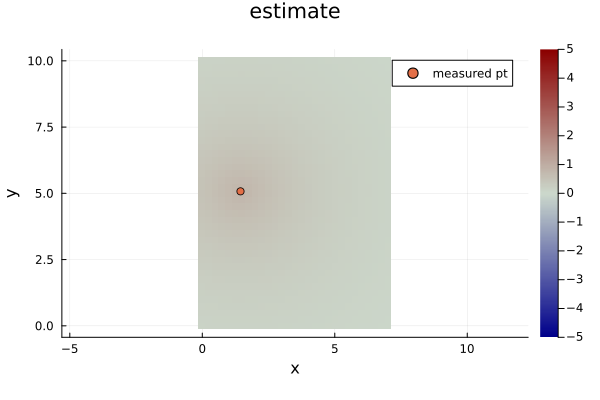

In [33]:
plot(problem, state_1_1; plot_type=:estimate, clims=(-5, 5), cmap=:bluesreds, aspect_ratio=:equal)
scatter!([measure_pt[1]], [measure_pt[2]], label="measured pt")

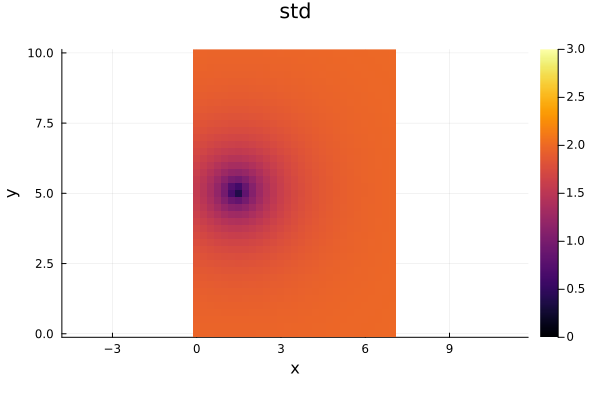

In [34]:
plot(problem, state_1_1; plot_type=:std, clims=(0, 3), aspect_ratio=:equal)

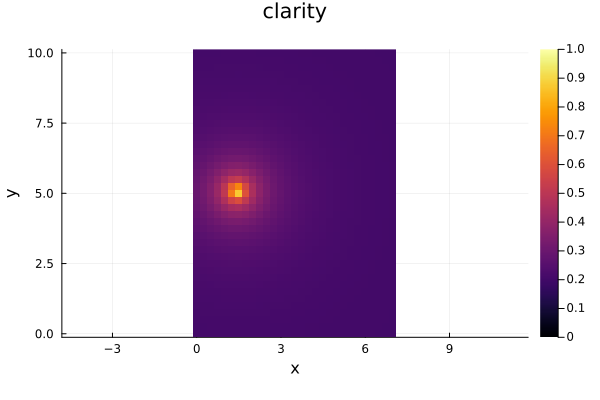

In [35]:
plot(problem, state_1_1; plot_type=:clarity, clims=(0, 1), aspect_ratio=:equal)

In [36]:
# propagate to the next time step

In [38]:
@time state_2_1 = stgpkf_predict(problem, state_1_1)

  0.875670 seconds (51 allocations: 173.222 MiB, 0.45% gc time)


KFState{Float64, Vector{Float64}, Matrix{Float64}}([1.3298517650962889, -0.0005874103212140304, 1.33814424416366, -0.0005910732014842028, 1.340417670745858, -0.0005920773993007984, 1.3372673561456687, -0.0005906858702899778, 1.3289956849635092, -0.0005870321810942219  …  0.5820667601747535, -0.00025710536432420013, 0.5421027662669569, -0.00023945282355648936, 0.5043385644953952, -0.00022277195545129997, 0.4687329608137602, -0.00020704456414003282, 0.43520952027966425, -0.00019223688745818328], [529.6996628676703 8.754161421542506e-6 … -0.006485916666963342 2.8649015572292096e-6; 0.0 -5.097132533612237 … -0.00029773488481363 1.3151281136385414e-7; … ; 0.0 0.0 … 529.625870244218 7.394996825355049e-5; 0.0 0.0 … 0.0 -5.0971310369744005])

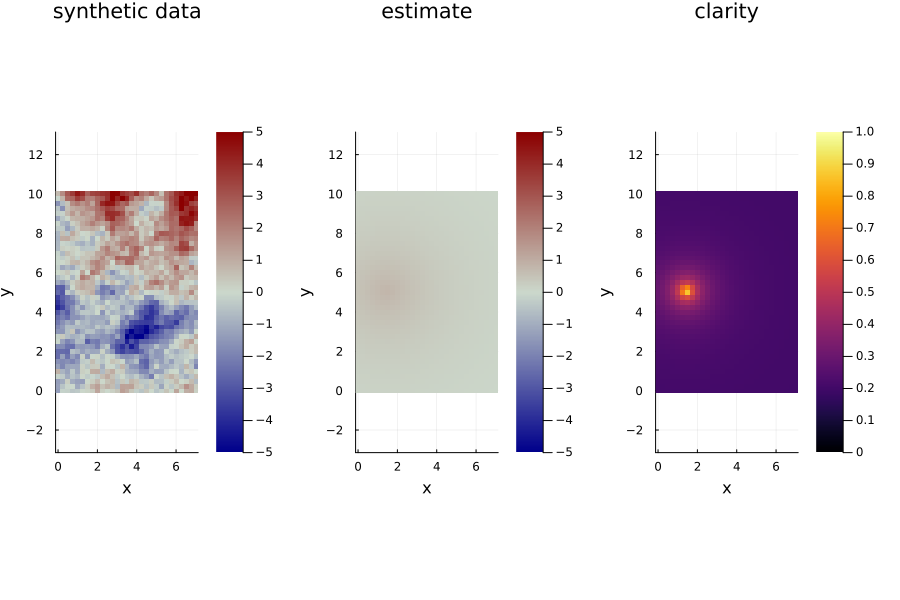

In [39]:
p0 = plot(synthetic_data, synthetic_data.ts[2]; clims=(-5, 5), cmap = :bluesreds, aspect_ratio=:equal)
title!("synthetic data")
p1 = plot(problem, state_2_1; plot_type=:estimate, clims=(-5, 5), cmap=:bluesreds, aspect_ratio=:equal)
p2 = plot(problem, state_2_1; plot_type=:clarity, clims=(0, 1), aspect_ratio=:equal)
plot(p0, p1, p2, layout=(@layout [a b c]), size=(900, 600))

In [40]:
# measure at a 10 different points at the same time
measure_pts = [rand_point(xs, ys) for i=1:10]
measure_ys = [measure(synthetic_data, pt..., synthetic_data.ts[2], measure_σ) for pt in measure_pts]
measure_Σ = (measure_σ^2) * I(10);

In [42]:
# do the KF correction
@time state_2_2 = stgpkf_correct(problem, state_2_1, measure_pts, measure_ys, measure_Σ)

  0.428504 seconds (125 allocations: 175.672 MiB, 3.93% gc time)


KFState{Float64, Vector{Float64}, Matrix{Float64}}([0.5388081729455987, -0.004385730236686142, 0.34304419311483914, -0.004413078078857277, 0.175550067896574, -0.004420575633069053, 0.06896477748386687, -0.004410186181883772, 0.05808421823686416, -0.004382906962226614  …  28.062273897390877, -0.001919603264716894, 26.95590567803678, -0.0017878056455683546, 25.80547534178913, -0.0016632627409222547, 24.730671879379745, -0.001545838696558359, 23.748113010418827, -0.001435281436984811], [-529.662723790638 -7.571452655665726e-6 … -0.0052885475528653934 -2.4778463017959043e-6; 0.0 5.097132238177488 … 4.24618207911948e-5 -3.2488176833264963e-7; … ; 0.0 0.0 … -470.4242064556343 -6.568382907174583e-5; 0.0 0.0 … 0.0 5.0971310369744005])

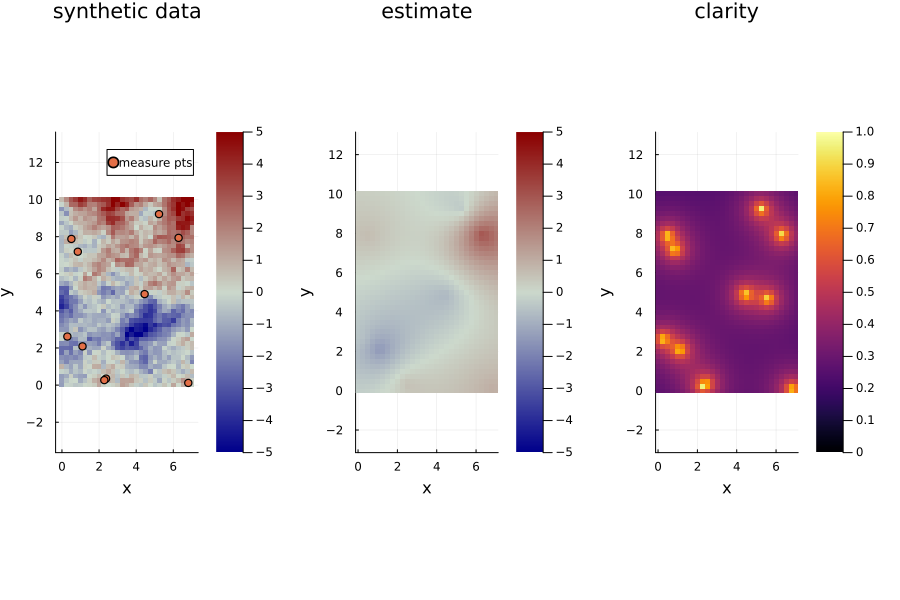

In [26]:
p0 = plot(synthetic_data, synthetic_data.ts[2]; clims=(-5, 5), cmap = :bluesreds, aspect_ratio=:equal)
title!("synthetic data")
scatter!(first.(measure_pts), last.(measure_pts), label="measure pts")
p1 = plot(problem, state_2_2; plot_type=:estimate, clims=(-5, 5), cmap=:bluesreds, aspect_ratio=:equal)
p2 = plot(problem, state_2_2; plot_type=:clarity, clims=(0, 1), aspect_ratio=:equal)
plot(p0, p1, p2, layout=(@layout [a b c]), size=(900, 600))

## Do a whole simulation

In [ ]:
# construct the state at time 0 conditioned on no measurements
state = stgpkf_initialize(problem) 

states = (typeof(state))[]

for k=1:length(synthetic_data.ts)

    @show k

    # make some measurements
    measure_pts = [rand_point(xs, ys) for i=1:10]
    measure_ys = [measure(synthetic_data, pt..., synthetic_data.ts[k], measure_σ) for pt in measure_pts]
    measure_Σ = (measure_σ^2) * I(10);

    # do the KF correction
    state_correction = stgpkf_correct(problem, state, measure_pts, measure_ys, measure_Σ)

    # add it to the states
    push!(states, state_correction)

    # do a prediction
    state = stgpkf_predict(problem, state_correction)

end

In [ ]:
states

In [ ]:
k = 40

p0 = plot(synthetic_data, synthetic_data.ts[k]; clims=(-5, 5), cmap = :bluesreds, aspect_ratio=:equal)
title!("synthetic data")
p1 = plot(problem, states[k]; plot_type=:estimate, clims=(-5, 5), cmap=:bluesreds, aspect_ratio=:equal)
p2 = plot(problem, states[k]; plot_type=:clarity, clims=(0, 1), aspect_ratio=:equal)
plot(p0, p1, p2, layout=(@layout [a b c]), size=(900, 600))

In [ ]:
@gif for k=1:length(states)
    p0 = plot(synthetic_data, synthetic_data.ts[k]; clims=(-5, 5), cmap = :bluesreds, aspect_ratio=:equal)
    title!("synthetic data")
    p1 = plot(problem, states[k]; plot_type=:estimate, clims=(-5, 5), cmap=:bluesreds, aspect_ratio=:equal)
    p2 = plot(problem, states[k]; plot_type=:clarity, clims=(0, 1), aspect_ratio=:equal)
    plot(p0, p1, p2, layout=(@layout [a b c]), size=(900, 600))
end

In [ ]:
@gif for k=1:length(states)
    p0 = plot(synthetic_data, synthetic_data.ts[k]; clims=(-5, 5), cmap = :bluesreds, aspect_ratio=:equal)
    title!("synthetic data")
    p1 = plot(problem, states[k]; plot_type=:estimate, clims=(-5, 5), cmap=:bluesreds, aspect_ratio=:equal)
    
    p2 = plot(problem, states[k]; plot_type=:percentile, percentile=0.05, clims=(-5, 5), cmap=:bluesreds, aspect_ratio=:equal)

    p3 = plot(problem, states[k]; plot_type=:percentile, percentile=0.95, clims=(-5, 5), cmap=:bluesreds, aspect_ratio=:equal)
    
    plot(p0, p1, p2, p3, layout=(@layout [a b; c d]), size=(900, 600))
end

In [ ]:
# check if the data is within the estimate

In [ ]:

tol = 0.1

fs = Float64[]
for k=1:length(states)
    M_05 = STGPKF.get_estimate_percentile(problem, states[k], tol/2)
    M_95 = STGPKF.get_estimate_percentile(problem, states[k], (1 - tol/2))
    M_true = vec(synthetic_data.data[:,:, k])
    f = sum(M_05 .<= M_true .<= M_95) / length(M_true)
    push!(fs, f)
end

In [ ]:
plot(100*fs, label="Measured")
hline!([100*(1 - tol)], label="Theory")
xlabel!("Time step")
title!("Percent of points estimated within tol of accuracy")
ylabel!("Percent [%]")